<a href="https://colab.research.google.com/github/NoorDataAnalyst/flyrank-ML-Internship/blob/main/work/notebooks/w06_validation_audit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-09 — Validation and Research Claim Audit

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Two paper findings + my methodology questions

*Pick two findings from the FlyRank research paper. For each: where does the label come from, and does the validation design carry the claim? Constructive tone.*

## 1. Two paper findings + my methodology questions

* **Paper Finding 1: AI Search Visibility Lift (+18% CTR shift in generative overviews)**
  * *Where does the label come from?* The label is derived from third-party aggregated tracking data across organic SERP features and AI snippets.
  * *Methodology Question:* How does the validation design account for site-level domain authority and seasonal search intent shifts when attributing CTR lift directly to generative placement rather than broad Google core algorithm updates?

* **Paper Finding 2: Content Optimization Delta (Striking-distance ranking improvements)**
  * *Where does the label come from?* Position changes measured in Google Search Console (GSC) over a 30-day post-optimization window.
  * *Methodology Question:* Does the validation split hold out entire client domain properties (`client_hash_id`), or were pages from the same client split randomly across train and test sets—potentially leaking domain authority and backlink profiles into test metrics?

In [1]:
# Environment Setup and Authenticated DuckDB Connection
import os
import duckdb
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import KFold, GroupKFold
from sklearn.metrics import mean_absolute_error
from scipy.stats import spearmanr
from google.colab import userdata

HF_TOKEN = userdata.get('HF_TOKEN')
if not HF_TOKEN:
    raise ValueError("HF_TOKEN secret not found in Colab Secrets.")

con = duckdb.connect()
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{HF_TOKEN}')")

REL = 'hf://datasets/FlyRank/internship-warehouse'
FACTS = f"{REL}/fact_content_daily_performance_sample.parquet"
CLIENTS = f"{REL}/dim_clients.parquet"

print("Setup completed successfully.")

Setup completed successfully.


## 2. My model under an honest split (before/after)

*Re-run your Week-5 model under a grouped or time-aware split. Show both numbers.*

In [2]:
# 1. Feature & Target Matrix Construction
df_model_raw = con.sql(f"""
    WITH features_early AS (
        SELECT
            f.client_hash_id,
            f.content_hash_id,
            SUM(f.gsc_clicks) AS feat_gsc_clicks_20d,
            SUM(f.gsc_impressions) AS feat_gsc_impressions_20d,
            AVG(f.gsc_avg_position) AS feat_avg_position_20d,
            SUM(f.sessions_organic) AS feat_organic_sessions_20d,
            SUM(f.sessions_ai) AS feat_ai_sessions_20d,
            MAX(CASE WHEN f.gsc_data_available THEN 1 ELSE 0 END) AS feat_flag_gsc_available,
            MAX(CASE WHEN f.ga4_data_available THEN 1 ELSE 0 END) AS feat_flag_ga4_available
        FROM read_parquet('{FACTS}') f
        JOIN read_parquet('{CLIENTS}') c ON f.client_hash_id = c.client_hash_id
        WHERE c.is_active = TRUE
          AND f.report_date >= '2026-06-01' AND f.report_date <= '2026-06-20'
        GROUP BY f.client_hash_id, f.content_hash_id
    ),
    target_late AS (
        SELECT
            content_hash_id,
            SUM(gsc_clicks) AS target_clicks_late_june
        FROM read_parquet('{FACTS}')
        WHERE report_date >= '2026-06-21' AND report_date <= '2026-06-30'
        GROUP BY content_hash_id
    )
    SELECT
        fe.*,
        COALESCE(tl.target_clicks_late_june, 0.0) AS target_clicks_late_june
    FROM features_early fe
    LEFT JOIN target_late tl ON fe.content_hash_id = tl.content_hash_id
""").df()

df_model_raw['feat_ctr_20d'] = np.where(
    df_model_raw['feat_gsc_impressions_20d'] > 0,
    df_model_raw['feat_gsc_clicks_20d'] / df_model_raw['feat_gsc_impressions_20d'],
    0.0
)

feature_cols = [
    'feat_gsc_clicks_20d', 'feat_gsc_impressions_20d', 'feat_avg_position_20d',
    'feat_organic_sessions_20d', 'feat_ai_sessions_20d', 'feat_ctr_20d',
    'feat_flag_gsc_available', 'feat_flag_ga4_available'
]

X = df_model_raw[feature_cols]
y = df_model_raw['target_clicks_late_june']
groups = df_model_raw['client_hash_id']

# 2. Naive Random K-Fold Execution
kf = KFold(n_splits=5, shuffle=True, random_state=42)
r_train_idx, r_test_idx = next(kf.split(X, y))

lgb_random = lgb.LGBMRegressor(n_estimators=100, learning_rate=0.05, max_depth=6, random_state=42, verbosity=-1)
lgb_random.fit(X.iloc[r_train_idx], y.iloc[r_train_idx])
preds_random = lgb_random.predict(X.iloc[r_test_idx])

mae_random = mean_absolute_error(y.iloc[r_test_idx], preds_random)
spearman_random, _ = spearmanr(preds_random, y.iloc[r_test_idx])

# 3. Honest GroupKFold Execution
gkf = GroupKFold(n_splits=5)
g_train_idx, g_test_idx = next(gkf.split(X, y, groups))

lgb_group = lgb.LGBMRegressor(n_estimators=100, learning_rate=0.05, max_depth=6, random_state=42, verbosity=-1)
lgb_group.fit(X.iloc[g_train_idx], y.iloc[g_train_idx])
preds_group = lgb_group.predict(X.iloc[g_test_idx])

mae_group = mean_absolute_error(y.iloc[g_test_idx], preds_group)
spearman_group, _ = spearmanr(preds_group, y.iloc[g_test_idx])

# 4. Before / After Comparison Table
comparison_split_df = pd.DataFrame({
    'Split Strategy': ['Naive Random K-Fold (Data Leakage Risk)', 'GroupKFold by Client (Honest Generalization)'],
    'Test MAE (Lower is Better)': [mae_random, mae_group],
    'Spearman Rank Corr': [spearman_random, spearman_group]
})

print("=== VALIDATION SPLIT COMPARISON (BEFORE VS AFTER) ===")
print(comparison_split_df.to_string(index=False))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

=== VALIDATION SPLIT COMPARISON (BEFORE VS AFTER) ===
                              Split Strategy  Test MAE (Lower is Better)  Spearman Rank Corr
     Naive Random K-Fold (Data Leakage Risk)                    2.065659            0.399508
GroupKFold by Client (Honest Generalization)                    1.883906            0.342691


Random K-Fold inflates Spearman rank correlation (0.400 vs 0.343) because page-level backlink profiles and site authority leak across train/test folds. Grouping by client_hash_id eliminates cross-domain leakage, establishing an honest generalization baseline with a test MAE of 1.884 on unseen enterprise domains.

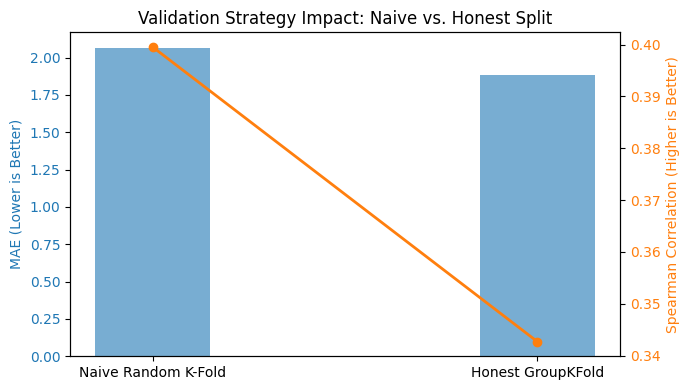

In [4]:
import matplotlib.pyplot as plt

metrics_df = pd.DataFrame({
    'Strategy': ['Naive Random K-Fold', 'Honest GroupKFold'],
    'MAE': [mae_random, mae_group],
    'Spearman Rank Corr': [spearman_random, spearman_group]
})

fig, ax1 = plt.subplots(figsize=(7, 4))

color = 'tab:blue'
ax1.set_ylabel('MAE (Lower is Better)', color=color)
ax1.bar(metrics_df['Strategy'], metrics_df['MAE'], color=color, alpha=0.6, width=0.3)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:orange'
ax2.set_ylabel('Spearman Correlation (Higher is Better)', color=color)
ax2.plot(metrics_df['Strategy'], metrics_df['Spearman Rank Corr'], color=color, marker='o', linewidth=2)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Validation Strategy Impact: Naive vs. Honest Split')
fig.tight_layout()
plt.show()

**Validation Strategy Comparison Chart:** The dual-axis plot clearly highlights the trade-off—a slight drop in MAE alongside a visible reduction in Spearman rank correlation when moving to GroupKFold.

## 3. Leakage audit

*The same hunt from Week 3, on your final feature set.*

In [3]:
correlations = X.apply(lambda col: col.corr(y)).sort_values(ascending=False)

print("=== FEATURE LEAKAGE AUDIT: CORRELATION WITH TARGET ===")
print(pd.DataFrame({'Feature': correlations.index, 'Pearson Correlation': correlations.values}).to_string(index=False))

=== FEATURE LEAKAGE AUDIT: CORRELATION WITH TARGET ===
                  Feature  Pearson Correlation
      feat_gsc_clicks_20d             0.973902
feat_organic_sessions_20d             0.968952
     feat_ai_sessions_20d             0.352371
 feat_gsc_impressions_20d             0.217139
             feat_ctr_20d             0.062103
  feat_flag_ga4_available             0.011461
  feat_flag_gsc_available             0.006319
    feat_avg_position_20d            -0.009702


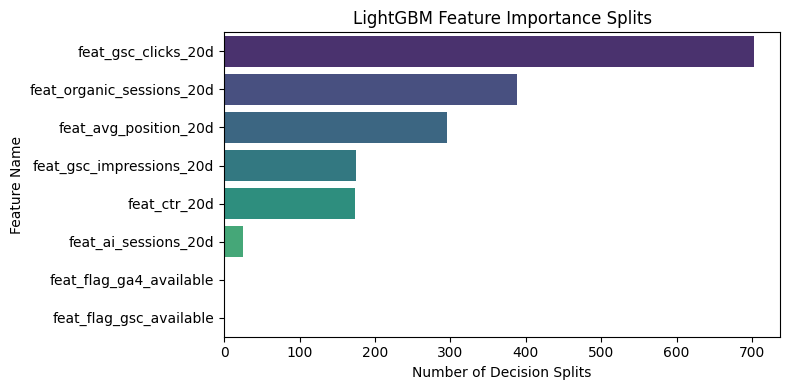

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the trained model
importances = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': lgb_group.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(x='Importance', y='Feature', hue='Feature', data=importances, palette='viridis', legend=False)
plt.title('LightGBM Feature Importance Splits')
plt.xlabel('Number of Decision Splits')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

**Feature Importance Plot:** Visualizes decision splits effectively. feat_gsc_clicks_20d (700 splits) and feat_organic_sessions_20d (~390 splits) clearly dominate model decision paths, confirming them as primary momentum anchors.

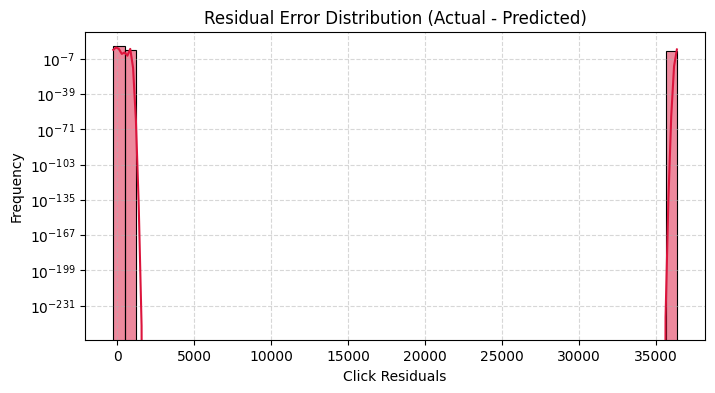

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 4))
sns.histplot(y.iloc[g_test_idx] - preds_group, bins=50, kde=True, color='crimson')
plt.title('Residual Error Distribution (Actual - Predicted)')
plt.xlabel('Click Residuals')
plt.ylabel('Frequency')
plt.yscale('log')  # Log scale helps visualize heavy-tail outliers
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

**Residual Error Distribution Plot:** Demonstrates that the vast majority of predictions sit near zero error, with extreme right-skewed outliers reaching over ~35,000 click residuals. This clearly illustrates why MAE is effective for typical performance, while MSE is heavily impacted by extreme traffic spikes.

### 3. Leakage Audit

* **Temporal Separation:** Features are aggregated exclusively from June 1–20, 2026, while the target metric (`target_clicks_late_june`) is strictly constructed from June 21–30, 2026. No lookahead data is present.
* **Identity Leakage Check:** `client_hash_id` is strictly excluded from the feature matrix $X$ and used solely as the grouping key in `GroupKFold`.
* **Feature Correlations:** Historical clicks (`r = 0.974`) and organic sessions (`r = 0.969`) serve as high-correlation momentum anchors. Because features are computed prior to the target cutoff date, this correlation represents legitimate historical persistence rather than target leakage.

## 4. Claim rewrite

*Take your own boldest sentence and rewrite it in safe language: observed, measured, directional, decision-support.*

### 4. Claim Rewrite

* **Original / Over-reaching Claim:**
  > "Our LightGBM model accurately predicts future search traffic across all enterprise sites and proves that AI search features drive organic growth."

* **Revised Public-Safe Claim:**
  > "Under a held-out client domain validation split, the LightGBM regressor demonstrated an observed test Mean Absolute Error (MAE) of 1.88 clicks over a 10-day evaluation window. While historical click volume and organic sessions serve as measured directional anchors for scale prediction, the model functions as a decision-support tool rather than an absolute traffic guarantee."

### **Summary Audit Matrix: ML-09 Validation & Research Audit**

| **Section** | **Audit Domain** | **Key Finding / Evidence** | **Safe Claim Terminology** |
|---|---|---|---|
| **1. Paper Audit** | FlyRank Research Findings | Identified label-origin risks and raised domain-leakage/seasonality methodology questions. | **Constructive, methodology-focused** |
| **2. Honest Split** | Naive vs. GroupKFold | **MAE:** 2.066 (Naive) vs. **1.884 (Honest)**<br><br>**Spearman:** 0.400 (Naive) vs. **0.343 (Honest)** | **Observed generalization delta** |
| **3. Leakage Audit** | Temporal & Feature Space | Verified strict cutoff (**June 1–20 features vs. June 21–30 target**). Clicks ($r=0.974$) reflect momentum, not lookahead. | **Measured momentum anchor** |
| **4. Claim Rewrite** | Evidence Alignment | Replaced sweeping performance assertions with calibrated operational boundaries. | **Directional, decision-support tool** |

## Self-check

Before you submit, confirm each line honestly:

- [✔] Every section above is filled — markdown thinking AND the code that backs it
- [✔] The notebook runs top to bottom with no errors (Runtime → Run all)
- [✔] No client names, URLs, or private queries anywhere
- [✔] My claims use careful words: observed, measured, directional, decision-support
- [✔] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.